In [1]:
import slmcontrol
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform
from cameras.ImagingSourceNew import ImagingSourceCamera
from cameras.Ximea import XimeaCamera
from scipy.linalg import inv
from utils import generate_amplitude_and_phase_hologram
from phase_screens import fourier_phase_screen
from augmented_gs import augmented_gs, fidelity
import jax
from utils import crop_center, resize_and_center, set_phase_reference

def remove_background(img, bg):
    return np.where(img > bg, img - bg, 0)

def capture_images(mode, phase, camera_direct, camera_fourier, roi_direct, roi_fourier, slm, bg_direct, bg_fourier, exposures):
    holo1 = generate_amplitude_and_phase_hologram(mode, np.zeros_like(mode), 192, -3, 19)
    slm.updateArray(holo1)

    camera_direct.set_exposure(exposures[0])
    camera_fourier.set_exposure(exposures[1])

    image_direct = camera_direct.capture(roi=roi_direct)
    image_fourier = camera_fourier.capture(roi=roi_fourier)

    holo2 = generate_amplitude_and_phase_hologram(mode, phase, 192, -3, 19)
    slm.updateArray(holo2)

    camera_fourier.set_exposure(exposures[2])

    image_phase_fourier = camera_fourier.capture(roi=roi_fourier)

    image_direct = remove_background(image_direct, bg_direct)
    image_fourier = remove_background(image_fourier, bg_fourier)
    image_phase_fourier = remove_background(image_phase_fourier, bg_fourier)

    return image_direct, image_fourier, image_phase_fourier

def fourier_transform(mode):
    return np.fft.fftshift(np.fft.fft2(np.fft.fftshift(mode)))

def inverse_fourier_transform(mode):
    return np.fft.fftshift(np.fft.ifft2(np.fft.fftshift(mode)))

def linear_transformation(input, A, output_shape=None):
    if not output_shape:
        output_shape = input.shape
    input_center = (np.array([*input.shape])) / 2
    output_center = (np.array([*output_shape])) / 2

    # Offset to align centers
    offset = input_center -  A @ output_center

    return affine_transform(input, A, offset, output_shape=output_shape)

In [2]:
slm = slmcontrol.SLMDisplay(host="localhost")
Ny, Nx = slm.height, slm.width // 2


with h5py.File("calibration/calibration.h5") as f:
    A_direct = f["A_direct"][:]
    t_direct = f["t_direct"][:]
    A_fourier = f["A_fourier"][:]
    t_fourier = f["t_fourier"][:]
    roi_direct = f["roi_direct"][:]
    roi_fourier = f["roi_fourier"][:]
    SIZE = f["SIZE"][()]

_xs = np.arange(SIZE) - SIZE // 2
_ys = np.arange(SIZE) - SIZE // 2
xs, ys = np.meshgrid(_xs, _ys)


In [3]:
camera_direct = ImagingSourceCamera()
camera_fourier = XimeaCamera()

In [54]:
modes = np.empty((8, *xs.shape), dtype=np.complex64)

modes[0] = slmcontrol.lg(xs, ys, p=0, l=1, w=30)
modes[1] = slmcontrol.lg(xs, ys, p=0, l=2, w=30)
modes[2] = slmcontrol.lg(xs, ys, p=0, l=-4, w=30)
modes[3] = slmcontrol.lg(xs, ys, p=1, l=-1, w=30)

modes[4] = slmcontrol.hg(xs, ys, m=1, n=0, w=30)
modes[5] = slmcontrol.diagonal_hg(xs, ys, m=2, n=2, w=30)

modes[6] = slmcontrol.lg(xs, ys, p=0, l=0, w=30) + slmcontrol.lg(xs, ys, p=0, l=1, w=30) + slmcontrol.lg(xs, ys, p=0, l=-2, w=30)

with h5py.File("../turbulence_compensation/data/output.h5") as file:
    data = file["fields"][:]
    u0 = np.sqrt(data[:, 0]) * np.exp(1j * data[:, 1])

modes[7] = resize_and_center(u0[0], (SIZE, SIZE), 0.8)

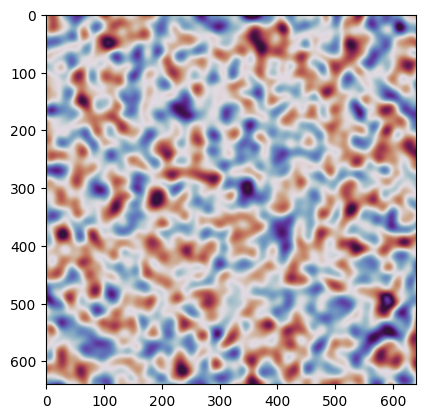

In [94]:
amplitude = 2

sigma = 0.08

phase_mask = fourier_phase_screen(slm.height, slm.width // 2, amplitude=amplitude, sigma=sigma)
phase_transformation = np.exp(1j * phase_mask)
cropped_phase_mask = crop_center(phase_mask, SIZE)
cropped_phase_transformation = np.exp(1j * cropped_phase_mask)

plt.imshow(cropped_phase_mask, cmap="twilight")

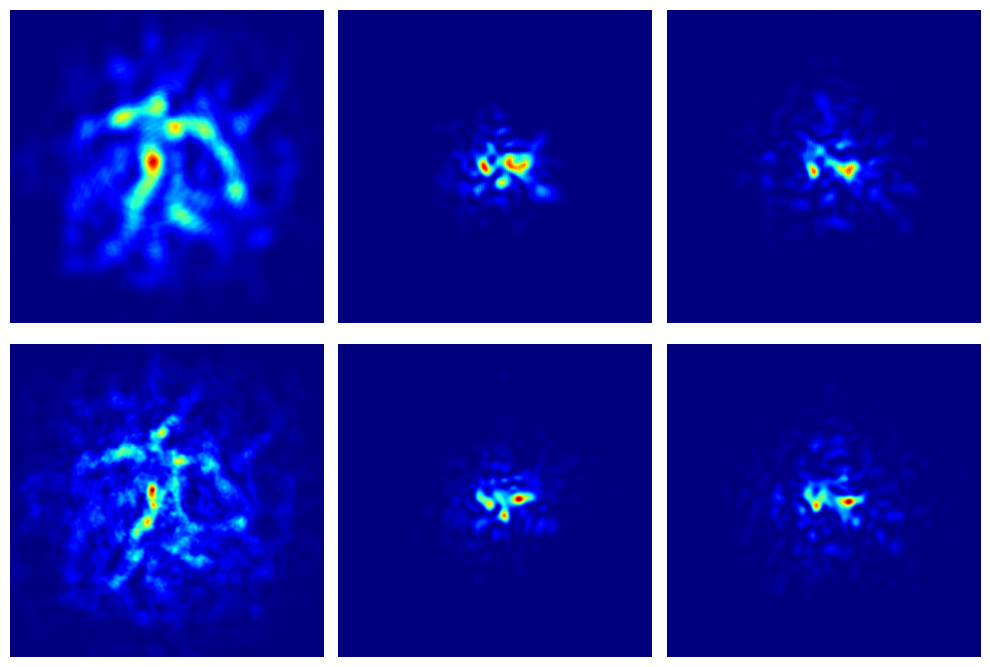

In [131]:
n = 7
mode = modes[n]
_mode = resize_and_center(mode, (Ny, Nx), 1)

exposures = (200, 150, 150)

image_direct, image_fourier, image_phase_fourier = capture_images(_mode, phase_mask, camera_direct, camera_fourier, roi_direct, roi_fourier, slm, 2, 5, exposures)

mode_fourier = fourier_transform(mode)
mode_phase_fourier = fourier_transform(mode * np.exp(1j * cropped_phase_mask))

theo_mode_direct = affine_transform(mode, inv(A_direct), - inv(A_direct) @ t_direct)
theo_mode_fourier = affine_transform(mode_fourier, inv(A_fourier), - inv(A_fourier) @ t_fourier)
theo_mode_phase_fourier = affine_transform(mode_phase_fourier, inv(A_fourier), - inv(A_fourier) @ t_fourier)


fig, axs = plt.subplots(2, 3, figsize=(10, 7))
axs[0, 0].imshow(image_direct, cmap="jet", vmin=0, vmax=255)
axs[0, 1].imshow(image_fourier, cmap="jet", vmin=0, vmax=255)
axs[0, 2].imshow(image_phase_fourier, cmap="jet", vmin=0, vmax=255)

axs[1, 0].imshow(np.abs(theo_mode_direct)**2, cmap="jet")
axs[1, 1].imshow(np.abs(theo_mode_fourier)**2, cmap="jet")
axs[1, 2].imshow(np.abs(theo_mode_phase_fourier)**2, cmap="jet")

for ax in axs.flatten():
    ax.axis("off")

plt.tight_layout()

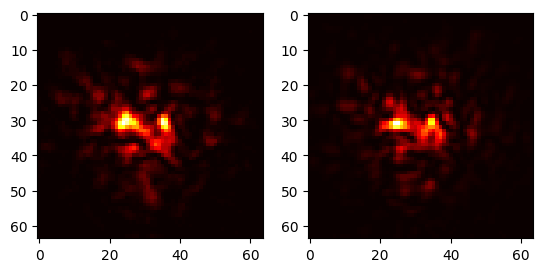

In [132]:
_image_direct = affine_transform(image_direct, A_direct, t_direct)
_image_fourier = affine_transform(image_fourier, A_fourier, t_fourier)
_image_phase_fourier = affine_transform(image_phase_fourier, A_fourier, t_fourier)

amplitude_direct = np.sqrt(_image_direct / _image_direct.sum())
amplitude_fourier = np.sqrt(_image_fourier / _image_fourier.sum())
amplitude_phase_fourier = np.sqrt(_image_phase_fourier / _image_phase_fourier.sum())


fig, axs = plt.subplots(1, 2)
axs[0].imshow(crop_center(_image_phase_fourier, 64), cmap="hot")
axs[1].imshow(crop_center(np.abs(mode_phase_fourier)**2, 64), cmap="hot")

In [133]:
initial_phase = jax.random.uniform(jax.random.key(0), (20, *amplitude_direct.shape))

predicted_phase = augmented_gs(
    amplitude_direct,
    np.fft.fftshift(amplitude_fourier),
    np.fft.fftshift(amplitude_phase_fourier),
    cropped_phase_transformation,
    initial_phase,
    100,
)

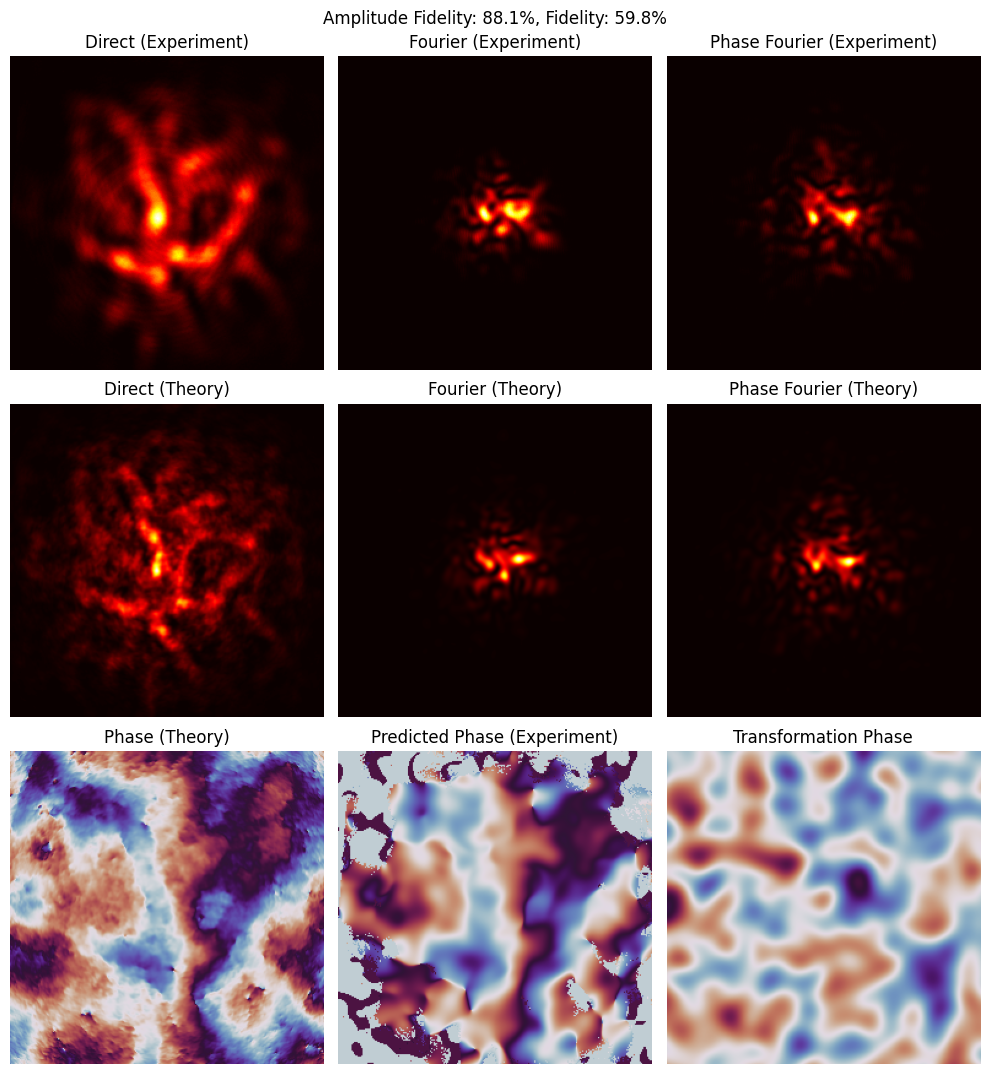

In [134]:
predicted_mode = amplitude_direct * np.exp(1j * predicted_phase)

CROP = 256

fid = fidelity(predicted_mode, mode)
amplitude_fid = fidelity(np.complex64(amplitude_direct), np.complex64(np.abs(mode)))



fig, axs = plt.subplots(3, 3, figsize=(10, 11))
fig.suptitle(f"Amplitude Fidelity: {amplitude_fid:.1%}, Fidelity: {fid:.1%}")
axs[0, 0].imshow(crop_center(amplitude_direct**2, CROP), cmap="hot")
axs[0, 0].set_title("Direct (Experiment)")

axs[0, 1].imshow(image_fourier, cmap="hot")
axs[0, 1].set_title("Fourier (Experiment)")

axs[0, 2].imshow(image_phase_fourier, cmap="hot")
axs[0, 2].set_title("Phase Fourier (Experiment)")

axs[1, 0].imshow(crop_center(np.abs(mode)**2, CROP), cmap="hot")
axs[1, 0].set_title("Direct (Theory)")

axs[1, 1].imshow(np.abs(theo_mode_fourier)**2, cmap="hot")
axs[1, 1].set_title("Fourier (Theory)")

axs[1, 2].imshow(np.abs(theo_mode_phase_fourier)**2, cmap="hot")
axs[1, 2].set_title("Phase Fourier (Theory)")

axs[2, 0].imshow(set_phase_reference(crop_center(np.angle(mode), CROP), posX = 0.4, posY = 0.4), cmap="twilight", vmin=-np.pi, vmax=np.pi)
axs[2, 0].set_title("Phase (Theory)")

axs[2, 1].imshow(set_phase_reference(crop_center(predicted_phase, CROP), posX = 0.4, posY = 0.4), cmap="twilight", vmin=-np.pi, vmax=np.pi)
axs[2, 1].set_title("Predicted Phase (Experiment)")

axs[2, 2].imshow(crop_center(cropped_phase_mask, CROP), cmap="twilight", vmin=-np.pi, vmax=np.pi)
axs[2, 2].set_title("Transformation Phase")

for ax in axs.flatten():
    ax.axis("off")

plt.tight_layout()

In [135]:
import os
dir = f"plots/retrieval/sigma={sigma}"
os.makedirs(dir, exist_ok=True)

fig.savefig(os.path.join(dir, f"mode{n}.png"))